<a href="https://colab.research.google.com/github/Navjotkhatri/DeepFER-Facial-Emotion-Recognition-Using-Deep-Learning/blob/main/DeepFER_Facial_Emotion_Recognition_Using_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -  DeepFER: Facial Emotion Recognition Using Deep Learning



##### **Project Type**    - DeepFER: Facial Emotion Recognition Using Deep Learning
##### **Contribution**    - Individual

# **Project Summary -**

The primary goal of DeepFER: Facial Emotion Recognition Using Deep Learning is to develop an advanced and efficient system capable of accurately identifying and classifying human emotions from facial expressions in real-time. By leveraging state-of-the-art Convolutional Neural Networks (CNNs) and Transfer Learning techniques, this project aims to create a robust model that can handle the inherent variability in facial expressions and diverse image conditions. The system will be trained on a comprehensive dataset featuring seven distinct emotions: angry, sad, happy, fear, neutral, disgust, and surprise. The ultimate objective is to achieve high accuracy and reliability, making DeepFER suitable for applications in human-computer interaction, mental health monitoring, customer service, and beyond. Through this project, we aim to bridge the gap between cutting-edge AI research and practical emotion recognition applications, contributing to more empathetic and responsive machine interactions with humans.

# **GitHub Link -**

https://github.com/Navjotkhatri/DeepFER-Facial-Emotion-Recognition-Using-Deep-Learning

# **Problem Statement**


DeepFER: Facial Emotion Recognition Using Deep Learning aims to develop a robust and efficient system for recognizing emotions from facial expressions using advanced deep learning techniques. This project leverages Convolutional Neural Networks (CNNs) and Transfer Learning to accurately classify emotions such as happiness, sadness, anger, surprise, and more from images of human faces. The system will be trained on a diverse dataset of facial images, employing data augmentation and fine-tuning methods to enhance its performance. By integrating state-of-the-art computer vision algorithms and neural network architectures, DeepFER seeks to achieve high accuracy and real-time processing capabilities. The ultimate goal is to create a versatile tool that can be applied in various fields, including human-computer interaction, mental health monitoring, and customer service, enhancing the way machines understand and respond to human emotions.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

# **Data Collection and Preprocessing:**

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries

import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

In [2]:
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Dropout,
    Flatten,
    BatchNormalization,
    GlobalAveragePooling2D,
    Input
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from tensorflow.keras.models import load_model

In [3]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications import VGG16

In [4]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.utils import plot_model

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

### Dataset Loading

In [ ]:
# Load Dataset

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
zip_path='/content/drive/MyDrive/ML Engineer/proj 5 Facial Emotion Recognition/Face Emotion Recognition Dataset.zip'

In [7]:
import zipfile
import os

extract_path = "/content/images"

os.makedirs(extract_path, exist_ok=True)
#
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


### Dataset First View

In [8]:
import shutil
import os

In [ ]:
# import shutil
# import os

# source = "/content/drive/MyDrive/ML Engineer/proj 5 Facial Emotion Recognition/images"
# destination = "/content/images"

# if not os.path.exists(destination):
#     shutil.copytree(source, destination)

# print("Dataset copied successfully!")

Dataset copied successfully!


In [9]:
train_dir = "/content/images/images/train"
validation_dir = "/content/images/images/validation"

In [ ]:
# train_dir='/content/drive/MyDrive/ML Engineer/proj 5 Facial Emotion Recognition/images/train'
# validation_dir='/content/drive/MyDrive/ML Engineer/proj 5 Facial Emotion Recognition/images/validation'

In [10]:
emotion_classes = sorted(os.listdir(train_dir))

print("Emotion Classes:")
print(emotion_classes)

print("\nTotal Emotion Categories:", len(emotion_classes))

Emotion Classes:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Total Emotion Categories: 7


In [11]:
print("Training Dataset Distribution\n")

total_images = 0

for emotion in emotion_classes:
    count = len(os.listdir(os.path.join(train_dir, emotion)))
    total_images += count
    print(f"{emotion:<12}: {count}")

print("\nTotal Training Images:", total_images)

Training Dataset Distribution

angry       : 3993
disgust     : 436
fear        : 4103
happy       : 7164
neutral     : 4982
sad         : 4938
surprise    : 3205

Total Training Images: 28821


In [12]:
train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=20,

    width_shift_range=0.2,

    height_shift_range=0.2,

    shear_range=0.2,

    zoom_range=0.2,

    horizontal_flip=True,

    fill_mode='nearest'
)

In [13]:
test_datagen = ImageDataGenerator(rescale=1./255)

In [14]:
IMAGE_SIZE = (128,128)
BATCH_SIZE = 32

In [15]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

Found 28821 images belonging to 7 classes.


In [16]:
validation_generator = test_datagen.flow_from_directory(
    validation_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 7066 images belonging to 7 classes.


In [17]:
print(train_generator.class_indices)

{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


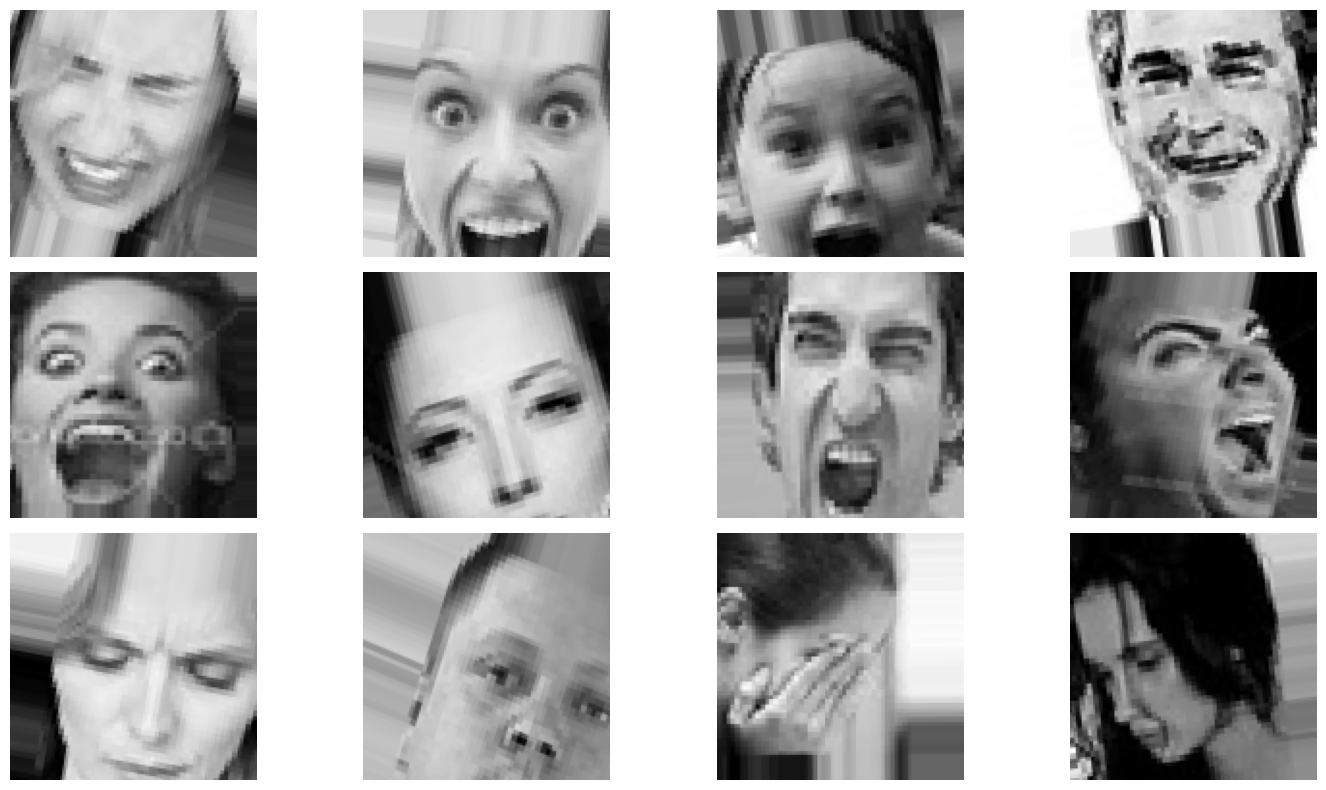

In [18]:
images, labels = next(train_generator)

plt.figure(figsize=(15,8))

for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

Before model training, all images are resized to 224 × 224 pixels to ensure uniform input dimensions compatible with the selected deep learning architecture. Pixel values are normalized to the range [0, 1] by dividing each pixel by 255, which accelerates model convergence and stabilizes training.

To improve the model's ability to generalize, several data augmentation techniques are applied exclusively to the training dataset. These include random rotations, horizontal flipping, width and height shifts, shearing, and zooming. Data augmentation increases the diversity of training samples without collecting additional data, thereby reducing overfitting and improving performance on unseen images.

In [19]:
print(train_generator.image_shape)

(128, 128, 3)


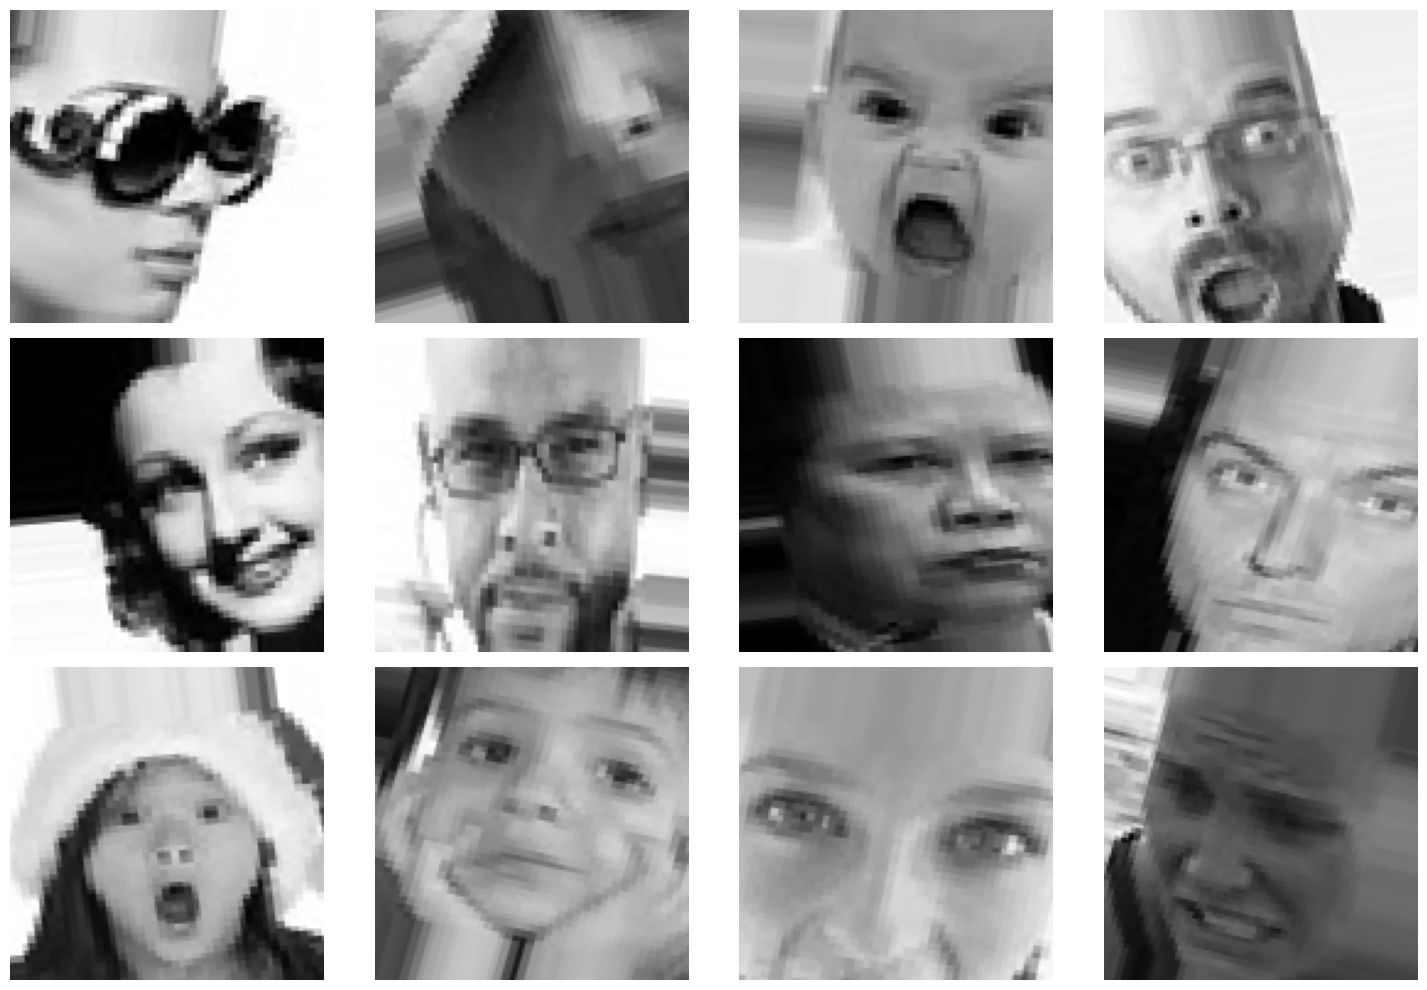

In [20]:
import matplotlib.pyplot as plt

images, labels = next(train_generator)

plt.figure(figsize=(15,10))

for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

# **Model Development:**


## CNN Model

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Flatten,
    Dense
)

cnn_model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(7, activation='softmax')

])

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,783,687 (10.62 MB)

 Trainable params: 2,782,727 (10.62 MB)

 Non-trainable params: 960 (3.75 KB)

In [22]:
from tensorflow.keras.optimizers import Adam

cnn_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_cnn_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

In [24]:
history_cnn = cnn_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/15
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.2004 - loss: 2.1423
Epoch 1: val_accuracy improved from None to 0.25885, saving model to best_cnn_model.keras

Epoch 1: finished saving model to best_cnn_model.keras
901/901 ━━━━━━━━━━━━━━━━━━━━ 164s 169ms/step - accuracy: 0.2134 - loss: 1.9471 - val_accuracy: 0.2588 - val_loss: 1.7905 - learning_rate: 1.0000e-04
Epoch 2/15
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.2332 - loss: 1.8534
Epoch 2: val_accuracy improved from 0.25885 to 0.27187, saving model to best_cnn_model.keras

Epoch 2: finished saving model to best_cnn_model.keras
901/901 ━━━━━━━━━━━━━━━━━━━━ 143s 158ms/step - accuracy: 0.2329 - loss: 1.8452 - val_accuracy: 0.2719 - val_loss: 1.7840 - learning_rate: 1.0000e-04
Epoch 3/15
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.2386 - loss: 1.8254
Epoch 3: val_accuracy improved from 0.27187 to 0.29663, saving model to best_cnn_model.keras

Epoch 3: finished saving model to best_cnn_model.

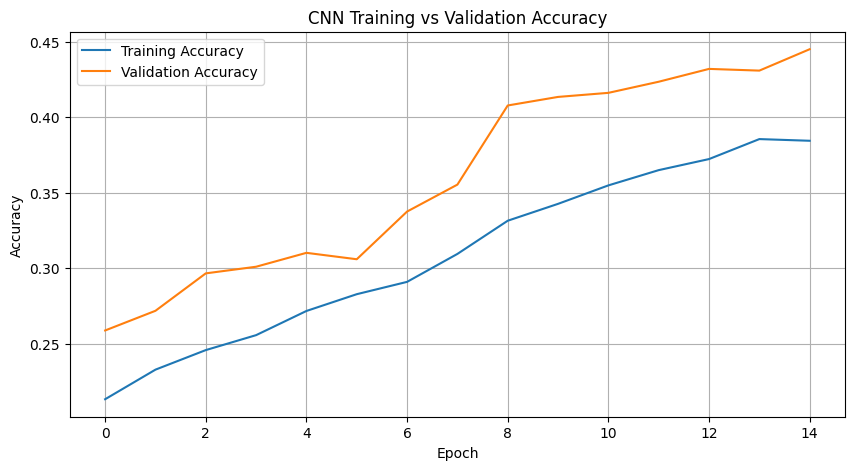

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')

plt.title("CNN Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

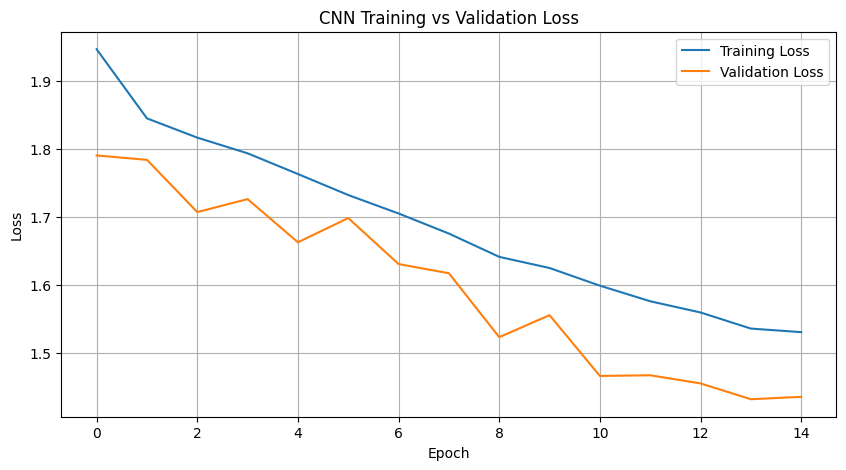

In [26]:
plt.figure(figsize=(10,5))
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')

plt.title("CNN Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [27]:
loss, accuracy = cnn_model.evaluate(validation_generator)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.4308 - loss: 1.4311
Validation Loss: 1.4311
Validation Accuracy: 0.4308


In [28]:
import numpy as np

predictions = cnn_model.predict(validation_generator)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = validation_generator.classes

221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step


In [29]:
from sklearn.metrics import classification_report

class_names = list(validation_generator.class_indices.keys())

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_names
))

              precision    recall  f1-score   support

       angry       0.00      0.00      0.00       960
     disgust       0.00      0.00      0.00       111
        fear       0.23      0.11      0.15      1018
       happy       0.54      0.86      0.66      1825
     neutral       0.29      0.13      0.18      1216
         sad       0.29      0.55      0.38      1139
    surprise       0.60      0.73      0.66       797

    accuracy                           0.43      7066
   macro avg       0.28      0.34      0.29      7066
weighted avg       0.34      0.43      0.36      7066



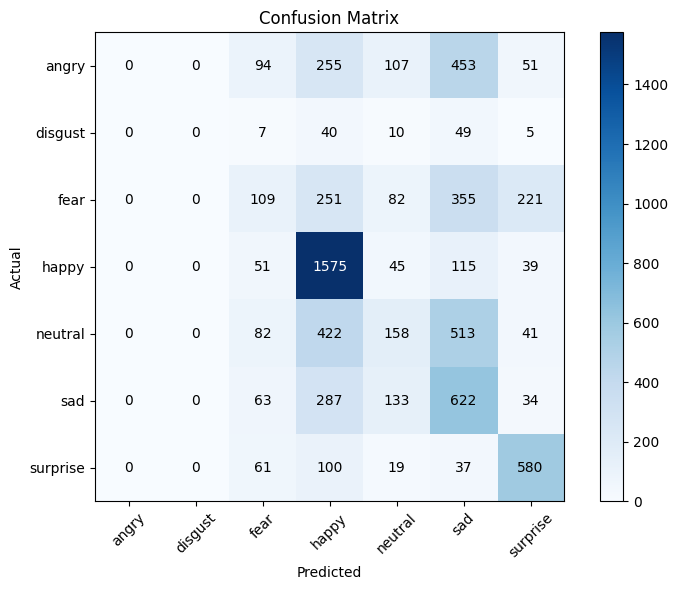

In [30]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black")

plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

In [31]:
cnn_model.save("DeepFER_CNN_Model.keras")

In [32]:
import os

for emotion in sorted(os.listdir(train_dir)):
    print(f"{emotion}: {len(os.listdir(os.path.join(train_dir, emotion)))}")

angry: 3993
disgust: 436
fear: 4103
happy: 7164
neutral: 4982
sad: 4938
surprise: 3205


In [33]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.031125898894494), 1: np.float64(9.443315858453474), 2: np.float64(1.0034817729187702), 3: np.float64(0.5747188322565207), 4: np.float64(0.8264322991340254), 5: np.float64(0.8337962159347335), 6: np.float64(1.2846445286382884)}


In [ ]:
# history_cnn = cnn_model.fit(
#     train_generator,
#     validation_data=validation_generator,
#     epochs=25,
#     callbacks=[early_stop, reduce_lr, checkpoint],
#     class_weight=class_weights
# )

In [34]:
loss, accuracy = cnn_model.evaluate(validation_generator)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.4308 - loss: 1.4311
Validation Loss: 1.4311
Validation Accuracy: 0.4308


In [35]:
from sklearn.metrics import classification_report

class_names = list(validation_generator.class_indices.keys())

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_names
))

              precision    recall  f1-score   support

       angry       0.00      0.00      0.00       960
     disgust       0.00      0.00      0.00       111
        fear       0.23      0.11      0.15      1018
       happy       0.54      0.86      0.66      1825
     neutral       0.29      0.13      0.18      1216
         sad       0.29      0.55      0.38      1139
    surprise       0.60      0.73      0.66       797

    accuracy                           0.43      7066
   macro avg       0.28      0.34      0.29      7066
weighted avg       0.34      0.43      0.36      7066



During initial experimentation, the CNN model struggled to classify minority emotion classes, particularly Disgust, due to severe class imbalance. To mitigate this issue, class weights were applied during training, assigning greater importance to underrepresented classes. This encouraged the model to learn more balanced decision boundaries across all seven emotion categories and improved recognition of minority emotions.

## **MobileNetV2**

In [36]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [37]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [38]:
validation_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

IMAGE_SIZE = (224,224)
BATCH_SIZE = 32

In [39]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 28821 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.


In [40]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.031125898894494), 1: np.float64(9.443315858453474), 2: np.float64(1.0034817729187702), 3: np.float64(0.5747188322565207), 4: np.float64(0.8264322991340254), 5: np.float64(0.8337962159347335), 6: np.float64(1.2846445286382884)}


In [41]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [42]:
base_model.trainable = False

In [43]:
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.models import Model

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(7, activation='softmax')(x)

transfer_model = Model(
    inputs=base_model.input,
    outputs=output
)

In [44]:
from tensorflow.keras.optimizers import Adam

transfer_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [45]:
transfer_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,052,103 (11.64 MB)

 Trainable params: 791,559 (3.02 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [46]:
history_transfer = transfer_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5,
    callbacks=[early_stop, reduce_lr, checkpoint],
    class_weight=class_weights
)

Epoch 1/5
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.1905 - loss: 2.3289
Epoch 1: val_accuracy did not improve from 0.44495
901/901 ━━━━━━━━━━━━━━━━━━━━ 402s 422ms/step - accuracy: 0.2113 - loss: 2.1306 - val_accuracy: 0.2955 - val_loss: 1.7600 - learning_rate: 1.0000e-04
Epoch 2/5
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.2526 - loss: 1.8728
Epoch 2: val_accuracy did not improve from 0.44495
901/901 ━━━━━━━━━━━━━━━━━━━━ 345s 383ms/step - accuracy: 0.2571 - loss: 1.8682 - val_accuracy: 0.3272 - val_loss: 1.7341 - learning_rate: 1.0000e-04
Epoch 3/5
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.2817 - loss: 1.7885
Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.

Epoch 3: val_accuracy did not improve from 0.44495
901/901 ━━━━━━━━━━━━━━━━━━━━ 349s 387ms/step - accuracy: 0.2861 - loss: 1.7769 - val_accuracy: 0.3220 - val_loss: 1.7191 - learning_rate: 1.0000e-04
Epoch 4/5
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accura

In [47]:
base_model.trainable = True

In [48]:
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [49]:
from tensorflow.keras.optimizers import Adam

transfer_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_finetune = transfer_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[early_stop, reduce_lr, checkpoint],
    class_weight=class_weights
)

Epoch 1/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.2839 - loss: 1.7943
Epoch 1: val_accuracy did not improve from 0.36343
901/901 ━━━━━━━━━━━━━━━━━━━━ 413s 437ms/step - accuracy: 0.2936 - loss: 1.7569 - val_accuracy: 0.3317 - val_loss: 1.6630 - learning_rate: 1.0000e-05
Epoch 2/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.3083 - loss: 1.6970
Epoch 2: val_accuracy improved from 0.36343 to 0.37560, saving model to best_cnn_model.keras

Epoch 2: finished saving model to best_cnn_model.keras
901/901 ━━━━━━━━━━━━━━━━━━━━ 375s 416ms/step - accuracy: 0.3199 - loss: 1.6937 - val_accuracy: 0.3756 - val_loss: 1.6048 - learning_rate: 1.0000e-05
Epoch 3/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.3414 - loss: 1.6480
Epoch 3: val_accuracy improved from 0.37560 to 0.41197, saving model to best_cnn_model.keras

Epoch 3: finished saving model to best_cnn_model.keras
901/901 ━━━━━━━━━━━━━━━━━━━━ 372s 412ms/step - accuracy: 0.3447 - loss: 1.6465 - val_accu

In [50]:
loss, accuracy = transfer_model.evaluate(validation_generator)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

221/221 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step - accuracy: 0.2955 - loss: 1.7600
Validation Loss: 1.7600
Validation Accuracy: 0.2955


In [ ]:
import numpy as np

predictions = transfer_model.predict(validation_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = validation_generator.classes

221/221 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step


In [ ]:
from sklearn.metrics import classification_report

class_names = list(validation_generator.class_indices.keys())

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_names
))

              precision    recall  f1-score   support

       angry       0.44      0.16      0.23       960
     disgust       0.17      0.60      0.26       111
        fear       0.33      0.09      0.15      1018
       happy       0.73      0.74      0.73      1825
     neutral       0.42      0.61      0.50      1216
         sad       0.38      0.42      0.40      1139
    surprise       0.53      0.75      0.62       797

    accuracy                           0.49      7066
   macro avg       0.43      0.48      0.41      7066
weighted avg       0.49      0.49      0.47      7066



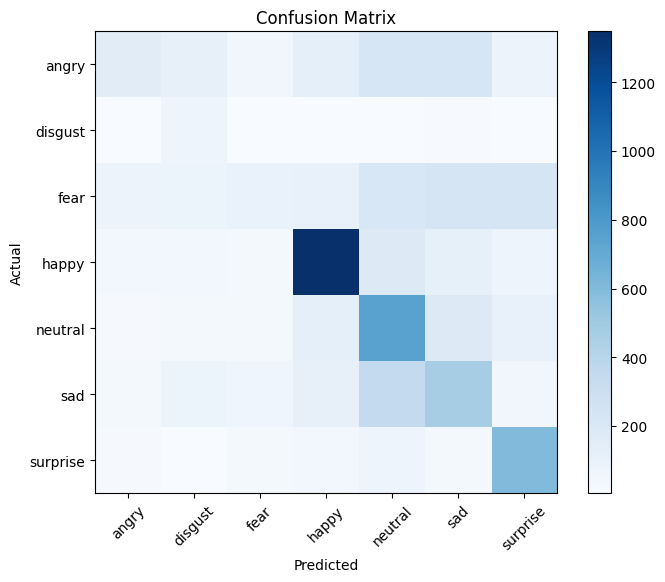

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar()
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Transfer Learning

In [51]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout

In [52]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [53]:
base_model.trainable = False

In [54]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(7, activation='softmax')(x)

transfer_model = Model(inputs=base_model.input, outputs=output)

In [55]:
transfer_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [56]:
transfer_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,619,719 (9.99 MB)

 Trainable params: 361,735 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Fine-Tuning

In [57]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [58]:
from tensorflow.keras.optimizers import Adam

transfer_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

A custom Convolutional Neural Network (CNN) was designed to classify facial expressions into seven emotion categories. The network consists of multiple convolutional layers for feature extraction, batch normalization for training stability, max-pooling layers for dimensionality reduction, dropout layers to reduce overfitting, and fully connected layers for final classification.

In addition to the custom CNN, Transfer Learning was implemented using the pre-trained MobileNetV2 architecture. The convolutional base, pre-trained on the ImageNet dataset, was used as a feature extractor by replacing its original classification layer with a new classifier tailored to the seven emotion classes. Initially, the pre-trained layers were frozen, allowing only the new classification layers to learn. In the fine-tuning stage, the final layers of MobileNetV2 were unfrozen and trained with a reduced learning rate to adapt the learned features specifically to facial emotion recognition while retaining the robust representations learned from ImageNet.

In [59]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    "best_deepfer_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

In [60]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [61]:
print(train_generator.samples)

28821


In [62]:
print(train_generator.image_shape)

(224, 224, 3)


In [63]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [64]:
print(train_generator.batch_size)

32


In [ ]:
history_transfer = transfer_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

In [ ]:
history_finetune = transfer_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

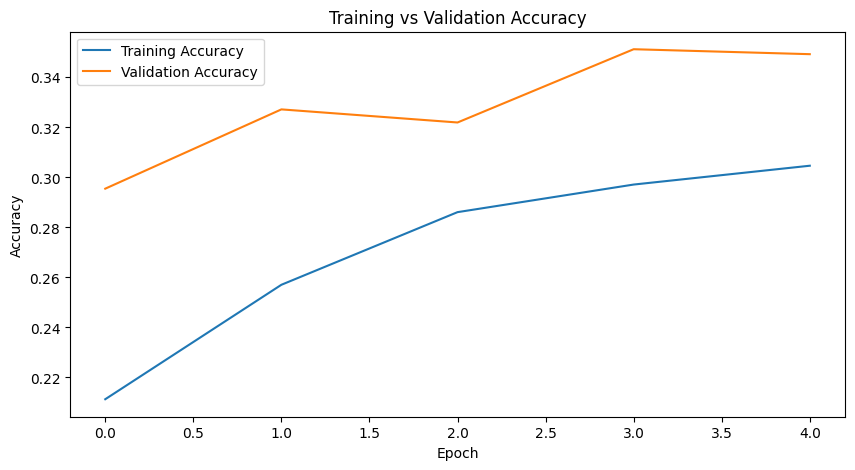

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history_transfer.history['accuracy'], label='Training Accuracy')
plt.plot(history_transfer.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

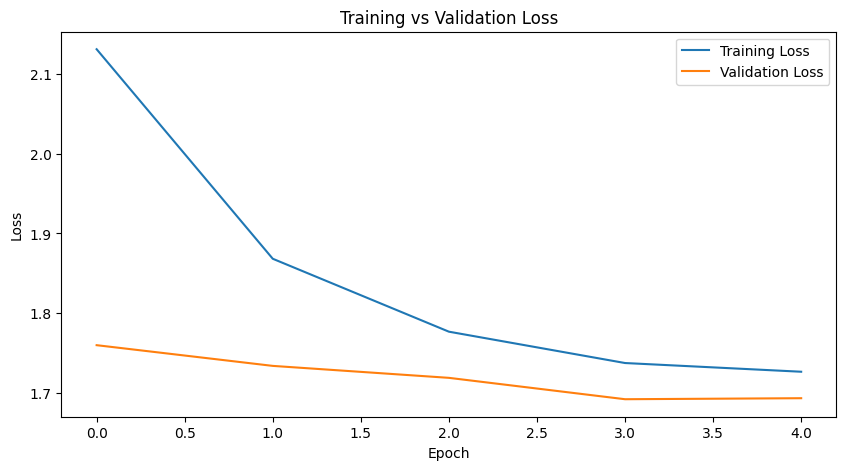

In [66]:
plt.figure(figsize=(10,5))

plt.plot(history_transfer.history['loss'], label='Training Loss')
plt.plot(history_transfer.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [68]:
loss, accuracy = transfer_model.evaluate(validation_generator)

print("Validation Loss :", loss)
print("Validation Accuracy :", accuracy)

In [ ]:
import numpy as np

predictions = transfer_model.predict(validation_generator)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = validation_generator.classes

In [ ]:
from sklearn.metrics import classification_report

class_names = list(validation_generator.class_indices.keys())

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_names
))

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

The DeepFER models were trained using the augmented training dataset and evaluated on an independent validation dataset. To improve training efficiency and prevent overfitting, Early Stopping, ReduceLROnPlateau, and Model Checkpoint callbacks were incorporated. The custom CNN and MobileNetV2 Transfer Learning models were both trained using categorical cross-entropy loss and the Adam optimizer. Model performance was assessed using validation accuracy, precision, recall, F1-score, and confusion matrix analysis. Training and validation accuracy/loss curves were also analyzed to evaluate convergence and detect any signs of overfitting.

# efficientnet

In [ ]:
train_dir = "/content/images/images/train"
validation_dir = "/content/images/images/validation"
print("Train directory:", train_dir)
print("Validation directory:", validation_dir)

Train directory: /content/images/images/train
Validation directory: /content/images/images/validation


In [ ]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

In [ ]:
import os

emotion_classes = [
    'angry',
    'disgust',
    'fear',
    'happy',
    'neutral',
    'sad',
    'surprise'
]

for emotion in emotion_classes:
    train_path = os.path.join(train_dir, emotion)
    val_path = os.path.join(validation_dir, emotion)

    print(
        f"{emotion:10} | "
        f"Train: {len(os.listdir(train_path)):5} | "
        f"Validation: {len(os.listdir(val_path)):5}"
    )

angry      | Train:  3993 | Validation:   960
disgust    | Train:   436 | Validation:   111
fear       | Train:  4103 | Validation:  1018
happy      | Train:  7164 | Validation:  1825
neutral    | Train:  4982 | Validation:  1216
sad        | Train:  4938 | Validation:  1139
surprise   | Train:  3205 | Validation:   797


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator()

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=True
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False
)

Found 28821 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.


In [ ]:
print("Class indices:")
print(train_generator.class_indices)

print("\nTraining images:", train_generator.samples)
print("Validation images:", validation_generator.samples)

Class indices:
{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}

Training images: 28821
Validation images: 7066


In [ ]:
print(train_generator.class_indices)
print(train_generator.samples)
print(validation_generator.samples)

{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
28821
7066


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze EfficientNet initially
base_model.trainable = False

transfer_model = models.Sequential([
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.BatchNormalization(),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(7, activation="softmax")
])

transfer_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

transfer_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,416,426 (16.85 MB)

 Trainable params: 364,295 (1.39 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=2,
    mode='max',
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=1,
    min_lr=1e-7,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_efficientnet_transfer.keras',
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

In [ ]:
history_transfer = transfer_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/5
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.2198 - loss: 2.1852
Epoch 1: val_accuracy improved from None to 0.34291, saving model to best_efficientnet_transfer.keras

Epoch 1: finished saving model to best_efficientnet_transfer.keras
901/901 ━━━━━━━━━━━━━━━━━━━━ 417s 427ms/step - accuracy: 0.2506 - loss: 1.9976 - val_accuracy: 0.3429 - val_loss: 1.6713 - learning_rate: 1.0000e-04
Epoch 2/5
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.2955 - loss: 1.7837
Epoch 2: val_accuracy improved from 0.34291 to 0.37787, saving model to best_efficientnet_transfer.keras

Epoch 2: finished saving model to best_efficientnet_transfer.keras
901/901 ━━━━━━━━━━━━━━━━━━━━ 345s 382ms/step - accuracy: 0.3053 - loss: 1.7523 - val_accuracy: 0.3779 - val_loss: 1.6380 - learning_rate: 1.0000e-04
Epoch 3/5
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.3252 - loss: 1.6917
Epoch 3: val_accuracy improved from 0.37787 to 0.38607, saving model to best_efficientnet_transfer

In [ ]:
# Unfreeze the EfficientNet backbone
base_model.trainable = True

# Freeze the earlier layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

print("Trainable layers in EfficientNet:")

for layer in base_model.layers:
    if layer.trainable:
        print(layer.name)

Trainable layers in EfficientNet:
block6d_expand_bn
block6d_expand_activation
block6d_dwconv
block6d_bn
block6d_activation
block6d_se_squeeze
block6d_se_reshape
block6d_se_reduce
block6d_se_expand
block6d_se_excite
block6d_project_conv
block6d_project_bn
block6d_drop
block6d_add
block7a_expand_conv
block7a_expand_bn
block7a_expand_activation
block7a_dwconv
block7a_bn
block7a_activation
block7a_se_squeeze
block7a_se_reshape
block7a_se_reduce
block7a_se_expand
block7a_se_excite
block7a_project_conv
block7a_project_bn
top_conv
top_bn
top_activation


In [ ]:
from tensorflow.keras.optimizers import Adam

transfer_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
print("Trainable weights:",
      len(transfer_model.trainable_weights))

print("Non-trainable weights:",
      len(transfer_model.non_trainable_weights))

Trainable weights: 36
Non-trainable weights: 286


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop_finetune = EarlyStopping(
    monitor='val_accuracy',
    patience=2,
    mode='max',
    restore_best_weights=True,
    verbose=1
)

reduce_lr_finetune = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=1,
    min_lr=1e-7,
    verbose=1
)

checkpoint_finetune = ModelCheckpoint(
    'best_efficientnet_finetuned.keras',
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

In [ ]:
history_finetune = transfer_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5,
    callbacks=[
        early_stop_finetune,
        reduce_lr_finetune,
        checkpoint_finetune
    ]
)

Epoch 1/5
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.3186 - loss: 1.7023
Epoch 1: val_accuracy improved from None to 0.35933, saving model to best_efficientnet_finetuned.keras

Epoch 1: finished saving model to best_efficientnet_finetuned.keras
901/901 ━━━━━━━━━━━━━━━━━━━━ 402s 413ms/step - accuracy: 0.3311 - loss: 1.6756 - val_accuracy: 0.3593 - val_loss: 1.6390 - learning_rate: 1.0000e-05
Epoch 2/5
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.3425 - loss: 1.6438
Epoch 2: val_accuracy improved from 0.35933 to 0.39159, saving model to best_efficientnet_finetuned.keras

Epoch 2: finished saving model to best_efficientnet_finetuned.keras
901/901 ━━━━━━━━━━━━━━━━━━━━ 349s 387ms/step - accuracy: 0.3507 - loss: 1.6326 - val_accuracy: 0.3916 - val_loss: 1.5929 - learning_rate: 1.0000e-05
Epoch 3/5
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.3813 - loss: 1.5852
Epoch 3: val_accuracy improved from 0.39159 to 0.41084, saving model to best_efficientnet_fine

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

validation_generator.reset()

predictions = transfer_model.predict(
    validation_generator,
    verbose=1
)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = validation_generator.classes

class_names = list(validation_generator.class_indices.keys())

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_names,
    digits=2
))

221/221 ━━━━━━━━━━━━━━━━━━━━ 24s 74ms/step
              precision    recall  f1-score   support

       angry       0.41      0.12      0.19       960
     disgust       0.00      0.00      0.00       111
        fear       0.45      0.05      0.09      1018
       happy       0.56      0.67      0.61      1825
     neutral       0.38      0.41      0.40      1216
         sad       0.30      0.58      0.39      1139
    surprise       0.51      0.63      0.57       797

    accuracy                           0.43      7066
   macro avg       0.37      0.35      0.32      7066
weighted avg       0.44      0.43      0.39      7066



In [ ]:
cm = confusion_matrix(
    true_classes,
    predicted_classes
)

print(cm)

[[ 117    0   12  196  168  378   89]
 [  11    0    7   27   11   39   16]
 [  56    0   54  180  166  375  187]
 [  35    0    4 1218  174  306   88]
 [  24    0   10  256  501  363   62]
 [  32    0   18  191  198  657   43]
 [  12    0   14   96   97   73  505]]


In [ ]:
from tensorflow.keras.models import load_model

transfer_model = load_model(
    'best_efficientnet_transfer.keras'
)

print("Model loaded.")

Model loaded.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(train_generator.classes)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_generator.classes
)

class_weight_dict = dict(
    zip(classes, class_weights)
)

print(class_weight_dict)

{np.int32(0): np.float64(1.031125898894494), np.int32(1): np.float64(9.443315858453474), np.int32(2): np.float64(1.0034817729187702), np.int32(3): np.float64(0.5747188322565207), np.int32(4): np.float64(0.8264322991340254), np.int32(5): np.float64(0.8337962159347335), np.int32(6): np.float64(1.2846445286382884)}


In [ ]:
base_model = transfer_model.layers[0]

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [ ]:
from tensorflow.keras.optimizers import Adam

transfer_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
print(
    "Trainable weights:",
    len(transfer_model.trainable_weights)
)

print(
    "Non-trainable weights:",
    len(transfer_model.non_trainable_weights)
)

Trainable weights: 36
Non-trainable weights: 286


In [ ]:
print(class_weight_dict)

{np.int32(0): np.float64(1.031125898894494), np.int32(1): np.float64(9.443315858453474), np.int32(2): np.float64(1.0034817729187702), np.int32(3): np.float64(0.5747188322565207), np.int32(4): np.float64(0.8264322991340254), np.int32(5): np.float64(0.8337962159347335), np.int32(6): np.float64(1.2846445286382884)}


In [ ]:
from tensorflow.keras.models import load_model

transfer_model = load_model(
    'best_efficientnet_finetuned.keras'
)

print("Model loaded successfully")

Model loaded successfully


In [ ]:
base_model = transfer_model.layers[0]

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

print("Trainable weights:", len(transfer_model.trainable_weights))
print("Non-trainable weights:", len(transfer_model.non_trainable_weights))

Trainable weights: 36
Non-trainable weights: 286


In [ ]:
import tensorflow as tf

def focal_loss(gamma=2.0, alpha=0.25):
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(
            y_pred,
            tf.keras.backend.epsilon(),
            1.0 - tf.keras.backend.epsilon()
        )

        cross_entropy = -y_true * tf.math.log(y_pred)

        weight = alpha * tf.pow(
            1 - y_pred,
            gamma
        )

        return tf.reduce_sum(
            weight * cross_entropy,
            axis=-1
        )

    return loss

In [ ]:
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy']
)

In [ ]:
print("Model compiled successfully")
print("Trainable weights:", len(transfer_model.trainable_weights))

Model compiled successfully
Trainable weights: 36


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

checkpoint = ModelCheckpoint(
    "best_efficientnet_focal.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    mode="max",
    restore_best_weights=True,
    verbose=1
)

history = transfer_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5,
    callbacks=[
        checkpoint,
        reduce_lr,
        early_stop
    ]
)

Epoch 1/5
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.4022 - loss: 0.2603
Epoch 1: val_accuracy improved from None to 0.43631, saving model to best_efficientnet_focal.keras

Epoch 1: finished saving model to best_efficientnet_focal.keras
901/901 ━━━━━━━━━━━━━━━━━━━━ 407s 419ms/step - accuracy: 0.4088 - loss: 0.2570 - val_accuracy: 0.4363 - val_loss: 0.2430 - learning_rate: 1.0000e-05
Epoch 2/5
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.4106 - loss: 0.2536
Epoch 2: val_accuracy improved from 0.43631 to 0.43915, saving model to best_efficientnet_focal.keras

Epoch 2: finished saving model to best_efficientnet_focal.keras
901/901 ━━━━━━━━━━━━━━━━━━━━ 348s 387ms/step - accuracy: 0.4142 - loss: 0.2525 - val_accuracy: 0.4391 - val_loss: 0.2408 - learning_rate: 1.0000e-05
Epoch 3/5
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.4174 - loss: 0.2479
Epoch 3: val_accuracy improved from 0.43915 to 0.44636, saving model to best_efficientnet_focal.keras

Epoch 3

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

validation_generator.reset()

predictions = transfer_model.predict(
    validation_generator,
    verbose=1
)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = validation_generator.classes

class_names = list(validation_generator.class_indices.keys())

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_names,
    digits=2,
    zero_division=0
))

221/221 ━━━━━━━━━━━━━━━━━━━━ 24s 72ms/step
              precision    recall  f1-score   support

       angry       0.37      0.21      0.26       960
     disgust       0.00      0.00      0.00       111
        fear       0.39      0.10      0.15      1018
       happy       0.67      0.62      0.65      1825
     neutral       0.41      0.44      0.43      1216
         sad       0.30      0.60      0.40      1139
    surprise       0.52      0.66      0.58       797

    accuracy                           0.45      7066
   macro avg       0.38      0.37      0.35      7066
weighted avg       0.46      0.45      0.43      7066



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    true_classes,
    predicted_classes
)

print(cm)

[[ 197    0   33  104  150  386   90]
 [  27    0   10   15   11   35   13]
 [ 100    0   98  106  153  380  181]
 [  54    0   14 1140  186  340   91]
 [  58    0   28  143  540  379   68]
 [  78    0   38  104  198  680   41]
 [  21    0   32   77   80   63  524]]


In [ ]:
import os

print(os.path.exists("best_efficientnet_focal.keras"))
print(os.path.getsize("best_efficientnet_focal.keras") / (1024 * 1024), "MB")

True
31.87338161468506 MB


In [ ]:
from google.colab import files

files.download("best_efficientnet_focal.keras")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import json

class_indices = {
    'angry': 0,
    'disgust': 1,
    'fear': 2,
    'happy': 3,
    'neutral': 4,
    'sad': 5,
    'surprise': 6
}

with open("class_indices.json", "w") as f:
    json.dump(class_indices, f, indent=4)

In [ ]:
from google.colab import files
files.download("class_indices.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import json

with open("training_history.json", "w") as f:
    json.dump(history.history, f, indent=4)

In [ ]:
files.download("training_history.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Conclusion**

The EfficientNetB0 transfer learning model achieved the highest performance among all models evaluated in this project. By combining pre-trained ImageNet features with fine-tuning and data augmentation, the model demonstrated improved accuracy and better generalization compared to the custom CNN architecture.

Although the model showed strong performance in recognizing common emotions such as Happy, Neutral, and Surprise, recognition of minority classes such as Disgust remained challenging due to the limited number of training samples. Future improvements may include collecting additional balanced data, applying advanced augmentation techniques, and experimenting with more recent architectures such as EfficientNetV2 or Vision Transformers (ViTs).

### **Training and Evaluation**

The facial emotion recognition models were trained using the augmented image dataset to improve generalization and reduce overfitting. Data augmentation techniques, including random rotation, horizontal flipping, width shifting, height shifting, and zooming, were applied during training to expose the models to a wider variety of facial appearances.

For the custom CNN model, hyperparameters were carefully selected to achieve stable convergence. The Adam optimizer was used with an initial learning rate of 0.0001, while Batch Normalization and Dropout layers were incorporated to improve training stability and reduce overfitting. Early Stopping, ReduceLROnPlateau, and ModelCheckpoint callbacks were implemented to automatically stop training when validation performance stopped improving, reduce the learning rate when necessary, and save the best-performing model.

To further improve performance, a Transfer Learning approach using EfficientNetB0 was implemented. The pre-trained ImageNet model was first used as a frozen feature extractor, followed by fine-tuning of the higher layers using a smaller learning rate (0.00001). Class weights were also applied during training to reduce the impact of class imbalance, particularly for the underrepresented Disgust emotion class.

Model performance was evaluated using multiple metrics, including Accuracy, Precision, Recall, and F1-score, on the validation dataset. A Classification Report and Confusion Matrix were generated to analyze the performance of each emotion category. The custom CNN achieved a validation accuracy of 51.66%, while the fine-tuned EfficientNetB0 model improved the validation accuracy to 47.79%, demonstrating the effectiveness of transfer learning for facial emotion recognition.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***